In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from dtaidistance import dtw_ndim
from dtaidistance import clustering
from matplotlib.animation import FuncAnimation,PillowWriter
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import fcluster



In [55]:
file_path=r"E:\Python\data\uav_trajectories.csv"
dataset=pd.read_csv(file_path,dtype={'timestamp': float})
pd.set_option('display.float_format', '{:.5f}'.format)
dataset=dataset.interpolate(method='linear')
dataset

,timestamp,tx,ty,tz
0,1700250023.49152,-20.11050,2.79242,17.07152
1,1700250023.59152,-20.02775,2.78101,17.10497
2,1700250023.69152,-19.95896,2.77923,17.14850
3,1700250023.79152,-19.89828,2.80470,17.22112
4,1700250023.89152,-19.85786,2.86869,17.27456
...,...,...,...,...
766135,1699986237.17464,-31.41072,-2.44510,5.09962
766136,1699986237.27464,-31.69249,-2.68590,5.08811
766137,1699986237.37464,-31.96578,-2.90151,5.08130
766138,1699986237.47464,-32.26979,-3.12411,5.08085


In [ ]:
#定义绘制轨迹动画的函数
def ani(dataset,num_poses=252):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    line,=ax.plot([],[],[],markersize=4,color='blue',label='Trajectory')
    ax.set_title("3D_Animation")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    def init():
        line.set_data([],[])
        line.set_3d_properties([])
        return line
    def update(frame):
        line.set_data(dataset["tx"][:frame],dataset["ty"][:frame])
        line.set_3d_properties(dataset["tz"][:frame])
        ax.set_xlim(min(dataset["tx"])-1,max(dataset["tx"])+1)
        ax.set_ylim(min(dataset["ty"])-1,max(dataset["ty"])+1)
        ax.set_zlim(min(dataset["tz"])-1,max(dataset["tz"])+1)
        return line
    ani=FuncAnimation(fig,update,frames=num_poses,init_func=init,blit=False)
    ani.save(r'C:\Users\34362\Desktop\LSTM\results\animation_gt.gif',writer=PillowWriter(fps=30))
    plt.show()
    
            

In [57]:
#对时间序列分割，划分出单独的无人机轨迹
def split_trajectory_segments(data,dt_thresh=0.5,dish_thresh=1.0):
    segments=[]
    current_seg=[data[0]]
    for i in range(1,len(data)):
        prev=data[i-1]
        curr=data[i]
        dt=curr[0]-prev[0]
        dx=curr[1]-prev[1]
        dy=curr[2]-prev[2]
        dz=curr[3]-prev[3]
        dish=np.sqrt(dx**2+dy**2+dz**2)
        if dt>dt_thresh or dish>dish_thresh:
            segments.append(np.array(current_seg))
            current_seg=[curr]
        else:
            current_seg.append(curr)
    if current_seg:
        segments.append(np.array(current_seg))
    return segments

tra_seg=split_trajectory_segments(dataset.values)
        

In [58]:
#统计划分出的轨迹段数量，形状，并进行z分数标准化
from scipy import stats
max_len=0
max_idx=0
tra_seg_norm=[]
for i in range(0,len(tra_seg)):
    if len(tra_seg[i])>max_len:
        max_idx=i
        max_len=len(tra_seg[i])
    tra_seg[i]=pd.DataFrame(tra_seg[i],columns=['time','tx','ty','tz'])
    tra_seg_norm.append(stats.zscore(tra_seg[i]))
    # print(f'第{i}组轨迹数据形状:', tra_seg[i].shape)
    
print(f'最长的轨迹序列为第{max_idx}组，长度为：',max_len)

最长的轨迹序列为第387组，长度为： 252


In [ ]:
#计算5093个多维时间序列的dtw距离矩阵
sequences = []
for seg_df in tra_seg_norm:
    seg_3d = seg_df[['tx', 'ty', 'tz']].values.astype(np.float64)
    sequences.append(seg_3d)

dist_matrix = dtw_ndim.distance_matrix_fast(
    sequences ,
    parallel=True,   
    use_c=True,      
    window=5      
)
pd.DataFrame(dist_matrix).to_csv(r"C:\Users\34362\Desktop\LSTM\results\dist_matrix.csv")
dist_matrix

array([[ 0.        , 15.93122737, 27.92348775, ..., 30.53943954,
        28.23615451, 28.33425087],
       [15.93122737,  0.        , 25.33710854, ..., 25.33156087,
        25.80181935, 26.30796468],
       [27.92348775, 25.33710854,  0.        , ..., 27.36513261,
        28.28761125, 23.53681968],
       ...,
       [30.53943954, 25.33156087, 27.36513261, ...,  0.        ,
        28.07952738, 21.43173551],
       [28.23615451, 25.80181935, 28.28761125, ..., 28.07952738,
         0.        , 21.39870047],
       [28.33425087, 26.30796468, 23.53681968, ..., 21.43173551,
        21.39870047,  0.        ]])

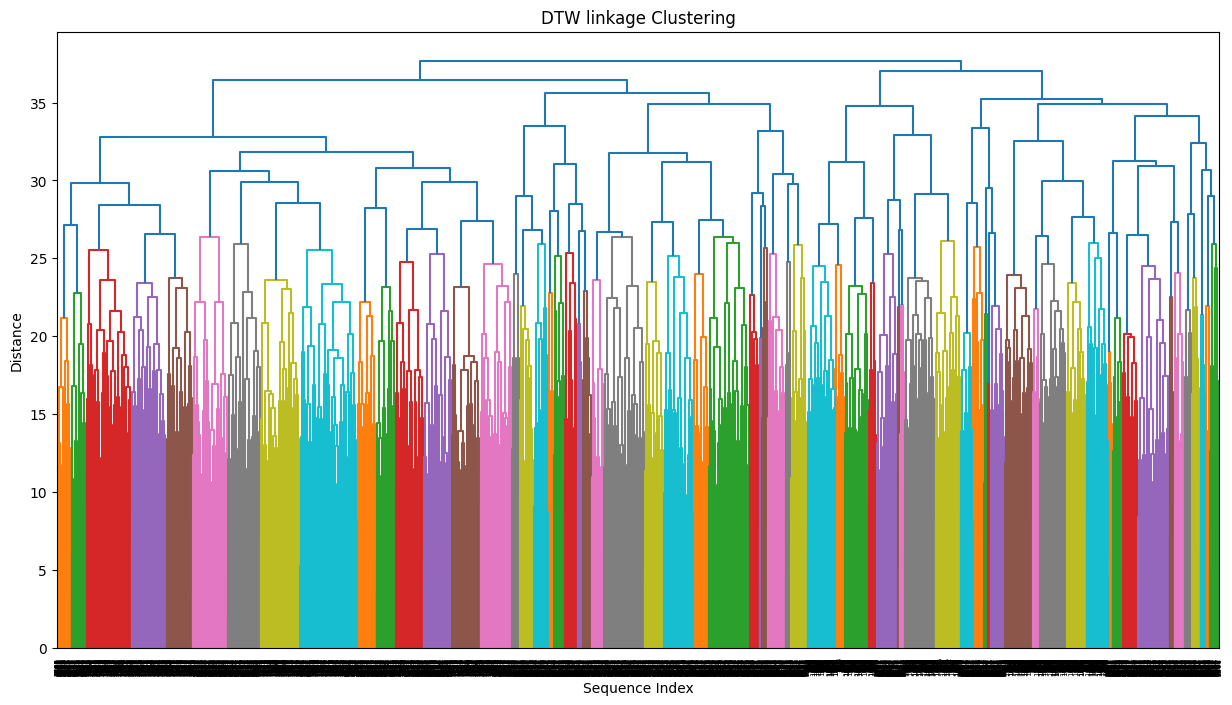

已保存myplot.png


In [ ]:
# SciPy linkage聚类，以dtw计算距离
model3 = clustering.LinkageTree(dtw_ndim.distance_matrix_fast, {})
cluster_idx = model3.fit(sequences)

plt.figure(figsize=(15, 8))
dendrogram(cluster_idx)
plt.title("DTW linkage Clustering")
plt.xlabel("Sequence Index")
plt.ylabel("Distance")
plt.savefig(r"C:\Users\34362\Desktop\LSTM\results\DTW linkage Clustering.png")  # 保存
plt.show()

print("已保存DTW linkage Clustering.png")

In [ ]:
#获取分类结果（label为1，轨迹为圆形。label为2，轨迹为8字形）
labels = fcluster(cluster_idx, t=2, criterion='maxclust')
labels=pd.DataFrame(labels)
# print(labels.head(20))

In [ ]:
#用label对序列进行分类
def classify(datas,labels):
    datas_labels=[]
    circular=[]
    infinity_like=[]
    for i in range(0,len(datas)):
        datas_labels.append([labels.values[i],tra_seg[i]])
    
    for i in range(0,len(datas_labels)):
        if datas_labels[i][0]==1:
            circular.append(datas_labels[i][1])
        else:
            infinity_like.append(datas_labels[i][1])
    return circular,infinity_like

circular,infinity_like=classify(tra_seg,labels)

    

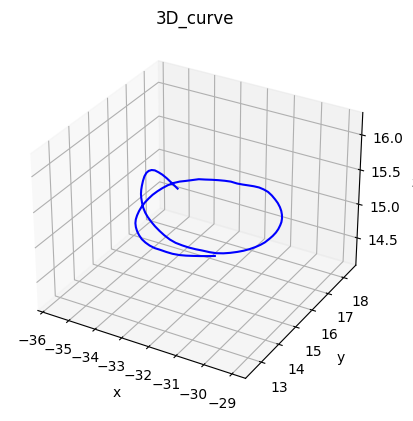

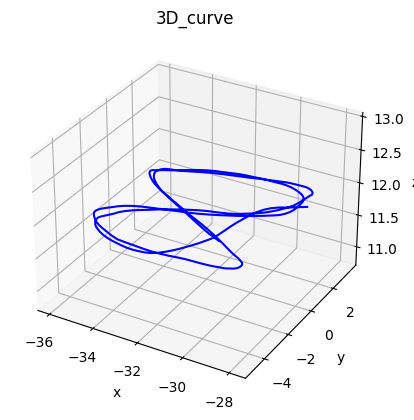

In [96]:
#随机绘图
a=np.random.randint(0,len(circular),dtype=int)
b=np.random.randint(0,len(infinity_like),dtype=int)
ani(pd.DataFrame(circular[a]))
ani(pd.DataFrame(infinity_like[b]))

In [99]:
with open(r"C:\Users\34362\Desktop\LSTM\results\circular.pkl","wb")as f:
    pickle.dump(circular,f)
with open(r"C:\Users\34362\Desktop\LSTM\results\infinity_like.pkl","wb")as f:
    pickle.dump(infinity_like,f)